In [ ]:
# STEP 1: Import libraries
import numpy as np
import pandas as pd

# For reproducibility (so you get same random numbers every time)
np.random.seed(42)

# STEP 2: Decide how many samples (rows of data) you want
n_samples = 5000  # you can change to 10000 later

# These lists will store each column
data = {
    "query_type": [],
    "num_rows_scanned": [],
    "result_rows": [],
    "num_joins": [],
    "has_index": [],
    "predicate_selectivity": [],
    "concurrent_users": [],
    "buffer_cache_size_mb": [],
    "cpu_cores": [],
    "disk_type": [],
    "response_time_ms": [],  # TARGET we want to predict
}

# STEP 3: Helper function to generate one row
def generate_one_row():
    # Categorical
    query_type = np.random.choice(["SELECT", "INSERT", "UPDATE"])
    disk_type = np.random.choice(["HDD", "SSD"])

    # Numeric (random but in realistic range)
    num_rows_scanned = np.random.randint(100, 200000)      # rows touched
    result_rows = np.random.randint(1, min(5000, num_rows_scanned))
    num_joins = np.random.randint(0, 4)                    # 0,1,2,3 joins
    has_index = np.random.choice([0, 1])                   # 0 = no, 1 = yes
    predicate_selectivity = np.random.uniform(0.001, 1.0)  # 0-1 percentage
    concurrent_users = np.random.randint(1, 101)           # 1 to 100 users
    buffer_cache_size_mb = np.random.choice([256, 512, 1024, 2048])
    cpu_cores = np.random.choice([2, 4, 8])

    # STEP 4: Define a fake "true" formula for response time

    # Base time grows with log of rows scanned (more rows -> slower)
    base_time = 5 * np.log(num_rows_scanned + 1)

    # More joins = slower
    base_time += 15 * num_joins

    # More concurrent users = contention
    base_time += 0.8 * concurrent_users

    # If index exists and predicate is selective (small fraction),
    # make query faster (subtract some time)
    if has_index == 1 and predicate_selectivity < 0.1:
        base_time -= 40

    # Bigger buffer cache helps
    if buffer_cache_size_mb >= 1024:
        base_time -= 20
    elif buffer_cache_size_mb >= 512:
        base_time -= 10

    # More CPU cores help
    if cpu_cores == 8:
        base_time -= 15
    elif cpu_cores == 4:
        base_time -= 5

    # SSD is faster than HDD
    if disk_type == "SSD":
        base_time -= 20

    # Make sure time does not go crazy low or negative
    base_time = max(5, base_time)

    # Add some noise so it's not perfectly predictable
    noise = np.random.normal(loc=0.0, scale=10.0)  # mean 0, std 10
    response_time_ms = base_time + noise

    # Again ensure it's at least 1 ms
    response_time_ms = max(1, response_time_ms)

    return {
        "query_type": query_type,
        "num_rows_scanned": num_rows_scanned,
        "result_rows": result_rows,
        "num_joins": num_joins,
        "has_index": has_index,
        "predicate_selectivity": predicate_selectivity,
        "concurrent_users": concurrent_users,
        "buffer_cache_size_mb": buffer_cache_size_mb,
        "cpu_cores": cpu_cores,
        "disk_type": disk_type,
        "response_time_ms": response_time_ms,
    }

# STEP 5: Generate all rows
for _ in range(n_samples):
    row = generate_one_row()
    for key in data.keys():
        data[key].append(row[key])

# STEP 6: Convert to DataFrame
df = pd.DataFrame(data)

# Show first 10 rows
print("First 10 rows:")
print(df.head(10))

# Basic statistics
print("\nSummary statistics:")
print(df.describe())

# STEP 7: Save to CSV (you can download this from Colab later)
df.to_csv("db_performance_data.csv", index=False)
print("\nSaved to db_performance_data.csv")


First 10 rows:
  query_type  num_rows_scanned  result_rows  num_joins  has_index  \
0     UPDATE            132032         3773          0          0   
1     UPDATE             64920          770          3          1   
2     SELECT             85405         4118          0          1   
3     UPDATE            130081         2735          1          0   
4     SELECT             41706         2889          2          1   
5     INSERT            120274         1479          3          0   
6     INSERT             19557         1022          1          1   
7     INSERT             99399         4912          2          1   
8     SELECT             82898         1077          3          1   
9     SELECT             40874         2569          3          0   

   predicate_selectivity  concurrent_users  buffer_cache_size_mb  cpu_cores  \
0               0.446387                87                  1024          8   
1               0.938614                 2                  2048   

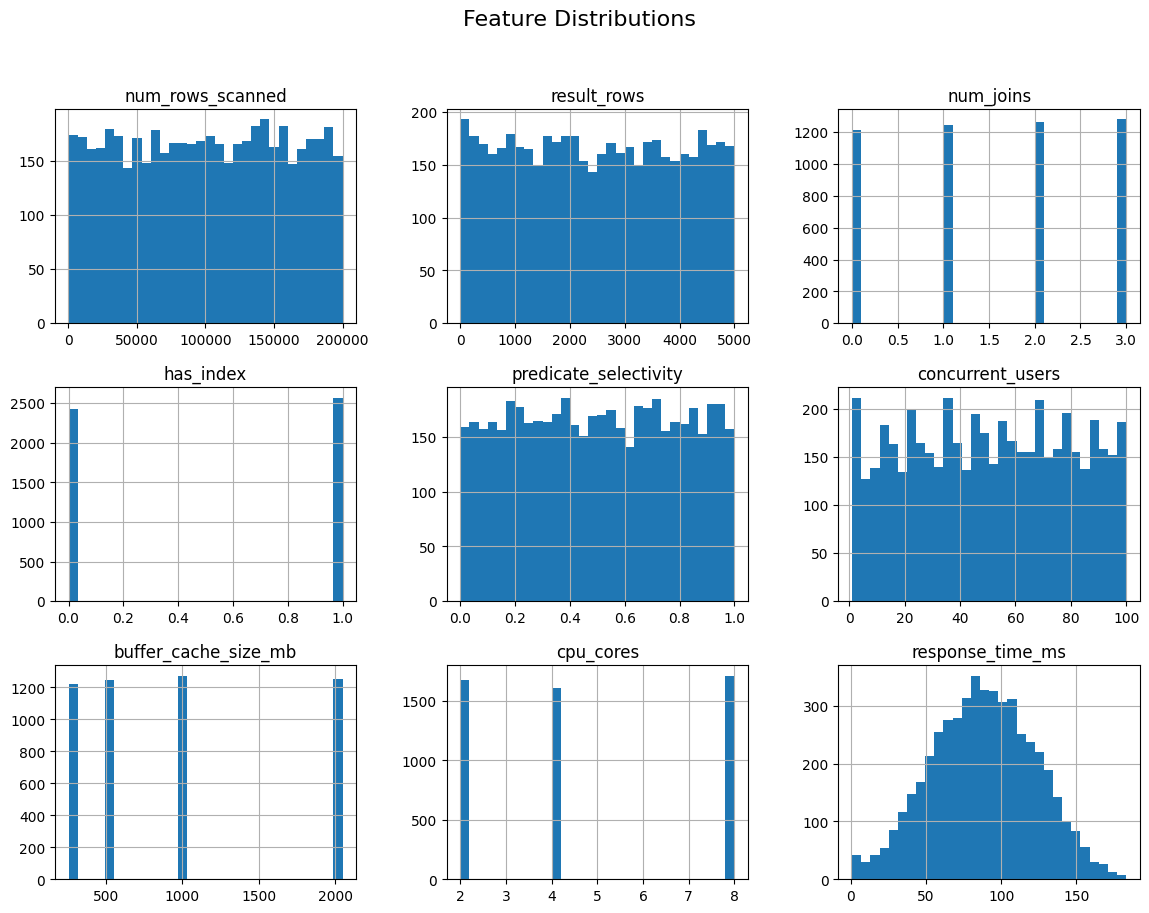

In [ ]:
import matplotlib.pyplot as plt

df.hist(figsize=(14, 10), bins=30)
plt.suptitle("Feature Distributions", fontsize=16)
plt.show()

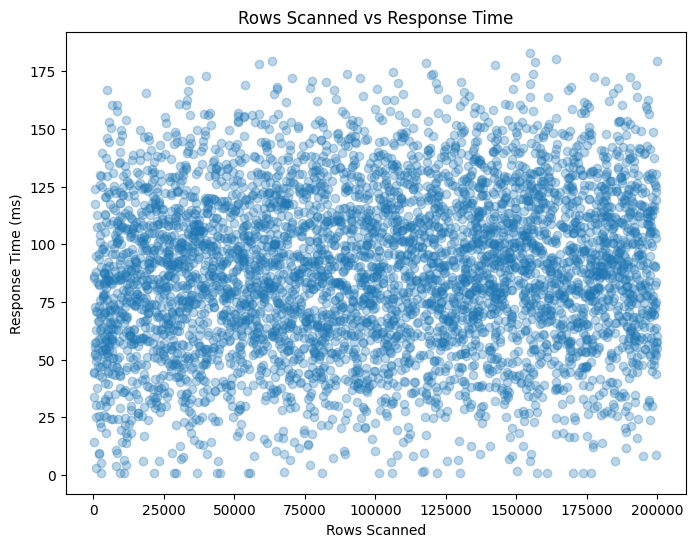

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(df['num_rows_scanned'], df['response_time_ms'], alpha=0.3)
plt.xlabel("Rows Scanned")
plt.ylabel("Response Time (ms)")
plt.title("Rows Scanned vs Response Time")
plt.show()

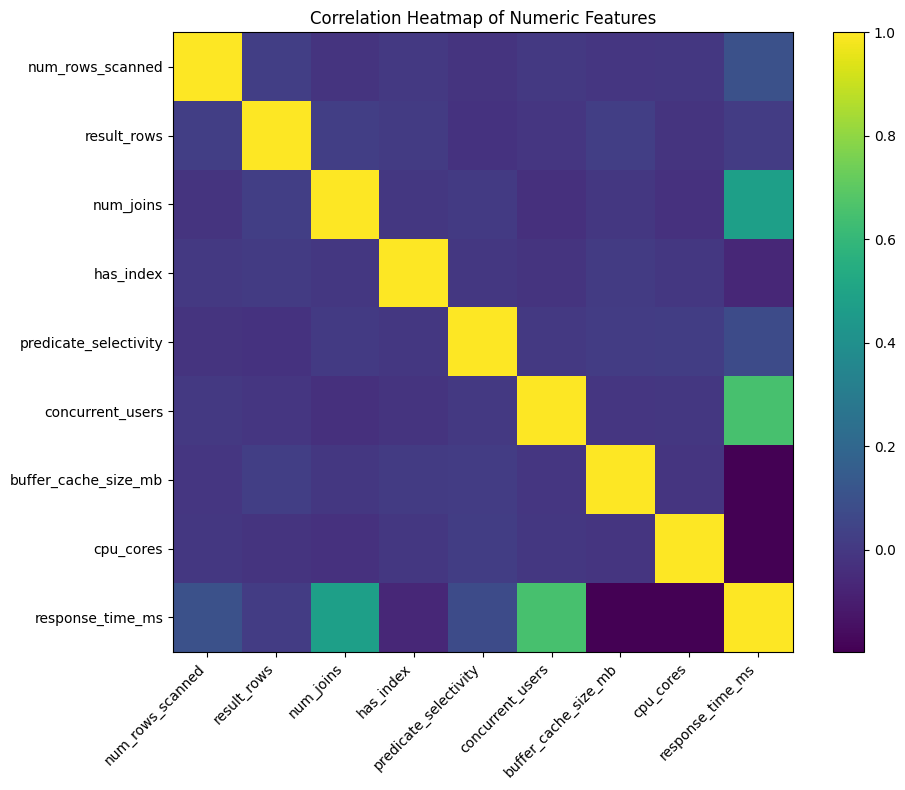

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Keep only numeric columns
numeric_df = df.select_dtypes(include=['number'])

# 2. Compute correlation matrix on numeric data
corr_matrix = numeric_df.corr()

# 3. Plot heatmap
plt.figure(figsize=(10, 8))
im = plt.imshow(corr_matrix, interpolation='nearest')
plt.colorbar(im)

# Set tick labels
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45, ha='right')
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. Separate features (X) and target (y)
X = df.drop("response_time_ms", axis=1)
y = df["response_time_ms"]

# 2. Identify categorical and numeric columns
categorical_cols = ["query_type", "disk_type"]
numeric_cols = [col for col in X.columns if col not in categorical_cols]

# 3. Preprocessing: OneHotEncode the categorical columns
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)

# 4. Create the full pipeline
model = LinearRegression()

# 5. Split into train & test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 6. Fit the preprocessor on training data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# 7. Train the linear regression model
model.fit(X_train_processed, y_train)

# 8. Make predictions
y_pred = model.predict(X_test_processed)

# 9. Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Linear Regression Results:")
print(f"MAE  (Mean Absolute Error): {mae:.2f} ms")
print(f"RMSE (Root Mean Squared Error): {rmse:.2f} ms")
print(f"R² Score: {r2:.3f}")

Linear Regression Results:
MAE  (Mean Absolute Error): 10.50 ms
RMSE (Root Mean Squared Error): 13.79 ms
R² Score: 0.834


In [ ]:
from sklearn.ensemble import RandomForestRegressor

# 1. Define the Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=200,      # number of trees
    max_depth=None,        # let trees grow fully
    random_state=42,
    n_jobs=-1              # use all CPU cores
)

# 2. Train
rf_model.fit(X_train_processed, y_train)

# 3. Predict
rf_pred = rf_model.predict(X_test_processed)

# 4. Evaluate
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Results:")
print(f"MAE:  {rf_mae:.2f} ms")
print(f"RMSE: {rf_rmse:.2f} ms")
print(f"R²:   {rf_r2:.3f}")

Random Forest Results:
MAE:  10.40 ms
RMSE: 13.38 ms
R²:   0.844


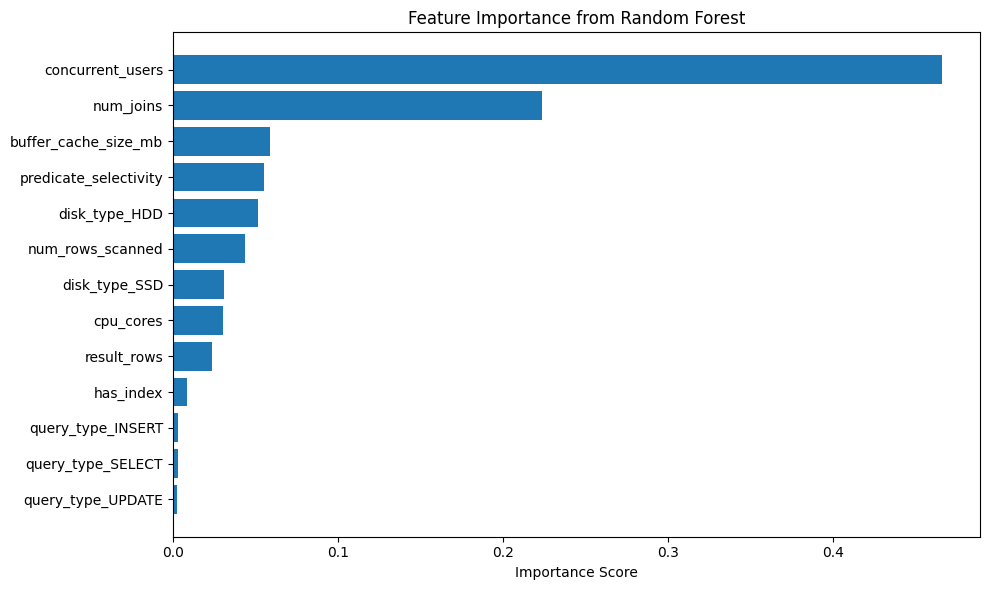

In [ ]:
# 1. Get encoded feature names
cat_feature_names = list(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols))
all_feature_names = cat_feature_names + numeric_cols

# 2. Get importances
importances = rf_model.feature_importances_

# 3. Plot
plt.figure(figsize=(10, 6))
indices = np.argsort(importances)
plt.barh([all_feature_names[i] for i in indices], importances[indices])
plt.title("Feature Importance from Random Forest")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

In [ ]:
def predict_response_time(query):
    input_df = pd.DataFrame([query])
    X_proc = preprocessor.transform(input_df)

    # predictions
    lr_pred = model.predict(X_proc)[0]
    rf_pred = rf_model.predict(X_proc)[0]

    # fix negative predictions
    lr_pred = max(1, lr_pred)
    rf_pred = max(1, rf_pred)

    print("Input query:")
    print(input_df)
    print("\nPredicted response time:")
    print(f"  Linear Regression (corrected): {lr_pred:.2f} ms")
    print(f"  Random Forest               : {rf_pred:.2f} ms")

    return lr_pred, rf_pred

In [ ]:
# Example 1: Simple, small query with index, SSD
easy_query = {
    "query_type": "SELECT",
    "num_rows_scanned": 5000,
    "result_rows": 100,
    "num_joins": 0,
    "has_index": 1,
    "predicate_selectivity": 0.01,  # very selective
    "concurrent_users": 5,
    "buffer_cache_size_mb": 2048,
    "cpu_cores": 8,
    "disk_type": "SSD",
}

print("=== EASY QUERY (Expected: Fast) ===")
predict_response_time(easy_query)

# Example 2: Heavy query, many rows, no index, many users, HDD
heavy_query = {
    "query_type": "SELECT",
    "num_rows_scanned": 150000,
    "result_rows": 4000,
    "num_joins": 3,
    "has_index": 0,
    "predicate_selectivity": 0.8,   # not selective
    "concurrent_users": 80,
    "buffer_cache_size_mb": 256,
    "cpu_cores": 2,
    "disk_type": "HDD",
}

print("\n=== HEAVY QUERY (Expected: Slow) ===")
predict_response_time(heavy_query)

=== EASY QUERY (Expected: Fast) ===
Input query:
  query_type  num_rows_scanned  result_rows  num_joins  has_index  \
0     SELECT              5000          100          0          1   

   predicate_selectivity  concurrent_users  buffer_cache_size_mb  cpu_cores  \
0                   0.01                 5                  2048          8   

  disk_type  
0       SSD  

Predicted response time:
  Linear Regression (corrected): 1.00 ms
  Random Forest               : 10.28 ms

=== HEAVY QUERY (Expected: Slow) ===
Input query:
  query_type  num_rows_scanned  result_rows  num_joins  has_index  \
0     SELECT            150000         4000          3          0   

   predicate_selectivity  concurrent_users  buffer_cache_size_mb  cpu_cores  \
0                    0.8                80                   256          2   

  disk_type  
0       HDD  

Predicted response time:
  Linear Regression (corrected): 165.52 ms
  Random Forest               : 156.31 ms


(np.float64(165.51981461758083), np.float64(156.3090267996659))